# Three-phase schedule: static vs dynamic bounded map

Ours only. The comparative study (phi sweep, sigmoid, PINN) is already done in
`LatentForecastComparisonMultiSeries.ipynb` and is not repeated here -- its
"Ours (two-stage)" row is carried in as the baseline to beat.

## The schedule

**Phase 1** -- train `E, r, D`. A bounded autoencoder that never sees the
3-dimensional bottleneck:

$$E(x_t)=h_t,\quad r(h_t)=C_t,\quad D(C_t)=\hat{x}_t,
\qquad \mathcal{L}=\mathrm{MSE}(\hat{x}_t,\,x_t)$$

**Phase 2** -- train `f, g, m`; freeze `E, r, D`. The loss lives in
$C$-space, against the frozen phase-1 code as target:

$$f(h_t)=b_t,\quad g(b_t)=b_{t+1},\quad m(b_{t+1})=\hat{C}_{t+1},
\qquad \mathcal{L}=\mathrm{MSE}(C_{t+1},\,\hat{C}_{t+1})$$

`D` is not used in this phase at all. Because `E` and `r` are frozen, both
$h_t$ and the target $C_{t+1}=r(h_{t+1})$ are constants and are precomputed
once.

**Phase 3** -- fine-tune `m` (carried from phase 2) and `D`; freeze `E, f, g, r`:

$$m(b_t)=\hat{C}_t,\quad D(\hat{C}_t)=\hat{x}_t,
\qquad \mathcal{L}=\mathrm{MSE}(\hat{C}_t,\,C_t)+\mathrm{MSE}(\hat{x}_t,\,x_t)$$

`g` is not used in this phase. `b_t` and `C_t` are both constants here and are
precomputed once.

## The two variants

Phase 3 is where they differ:

- **Variant A** -- static map, $m(b_t)=C_t$.
- **Variant B** -- dynamic map, $m(b_t, C_{t-1}) = C_t$, i.e.
  `Src.LatentMapping.LatentMappingDynamic`.

Phase 2 always uses the static map, since phase 3 discards it either way. That
keeps phases 1 and 2 **shared across both variants** -- they are trained once
per seed and phase 3 forks.

## Why `m` is in phase 2 at all

`f` needs a gradient. With `E, r, D` frozen and no `m`, the only available
objective is an MSE in `b`-space against the encoder's own `b`, which
collapses: `f` constant gives constant `b`, `g` the identity, and zero loss
with nothing learned. Routing through `m` to the frozen `C` target fixes this,
and phase 3 then fine-tunes that same `m`.

## Training budget

`E`, `r`, `f` and `g` are each trained in exactly one phase. `m` and `D` are
each trained in two, so both get double.

| module | E | r | f | g | m (A) | m (B) | D |
|---|---|---|---|---|---|---|---|
| passes | 60 | 60 | 60 | 60 | **120** | 60 | **120** |

`m (B)` is 60 rather than 120 because the dynamic map cannot inherit phase 2's
static weights -- see the note in phase 3.


In [1]:
import sys
import copy
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "Experimentation" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from Src import DecoupledModel
from Src.LatentMapping import LatentMapping, LatentMappingDynamic
from Utils import LoadLorenzMultiSeries, PALETTE, DPI, PlotLossCurves, PlotHorizonCurves
from Utils.Checkpoints import TrainOrLoad
from Utils.Metrics import (NRMSE, VPT, BoundViolation, Saturation, StepsPerLyapunov,
                           LAMBDA_MAX)
from Utils.Rollout import (EvaluateModel, ForecastMetrics, MeanRollout,
                           EvalWindowsFromTrajectories, MakeSeriesWindows)
from Utils.Benchmark import CountParams, EpochTrain, PinThreads, SeedAll


In [2]:
DATAPATH = ROOT / "Data" / "LorenzLiftMulti.npz"
assert DATAPATH.exists(), f"missing {DATAPATH}"

Multi = LoadLorenzMultiSeries(DATAPATH)
TrainSeries, ValSeries = Multi["train"], Multi["val"]
HoldoutObs = Multi["holdout_obs"]
N_SERIES = TrainSeries.shape[0]
train = TrainSeries.reshape(-1, TrainSeries.shape[-1])

print(f"train {TrainSeries.shape}  ({N_SERIES} series, {train.shape[0]:,} timesteps pooled)")


train (8, 14000, 30)  (8 series, 112,000 timesteps pooled)


In [3]:
# Identical to the main notebook's config -- these must not drift, or the
# "Ours (two-stage)" baseline row below stops being comparable.
N = train.shape[-1]
K = 3
A, B = 8, 8

DT = 0.01
STEPS_PER_LYAP = StepsPerLyapunov(DT)
WARM = 64
UNROLL = 20
HORIZON = 550
CLIMATE = 5500
THRESHOLD = 0.4

QUICK = False
EPOCHS = 5 if QUICK else 60          # same as the main experiment
MARKS = (1, 2, 5) if QUICK else (5, 10, 20, 40, 60)
SEEDS = [0] if QUICK else [0, 1, 2]

BATCH_P1 = 4096          # phase 1, per-timestep autoencoder
BATCH_P2 = 256           # phase 2, sequence training
BATCH_P3 = 512           # phase 3, m + D on precomputed tensors
SEQ_STRIDE = 4
LR = 1e-3
PLOT_EVERY = 10
NOISE_FLOOR = float(Multi["noise_floor_mse"])

# Variant B's recursion needs a C to start from. 0.5 is the neutral point of
# the box (logit 0), costs no parameters and no extra network, and the map
# still sees b_0 -- C_0 = m(b_0, 0.5).
C0_INIT = 0.5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
THREADS = PinThreads(8)

CKPT_DIR = ROOT / "Checkpoints" / "three_phase"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f"device {DEVICE}, threads {THREADS}")
print(f"{EPOCHS} epochs/phase, marks {MARKS}, seeds {SEEDS}")
print(f"noise floor {NOISE_FLOOR:.6f}")


device cpu, threads 8
60 epochs/phase, marks (5, 10, 20, 40, 60), seeds [0, 1, 2]
noise floor 0.002492


In [4]:
# torch.compile probe. Inductor has to emit and build C++ kernels, so it needs
# a host compiler; there is none on this machine (no cl.exe, no gcc). The probe
# module must carry an activation -- a bare nn.Linear compiles even with no
# toolchain, because inductor dispatches it straight to ATen addmm and never
# generates C++, so probing with one reports a false positive. Every net here
# is Linear + GELU/Sigmoid, which does need codegen.
def _ProbeCompile():
    try:
        m = nn.Sequential(nn.Linear(8, 16), nn.GELU(), nn.Linear(16, 8)).to(DEVICE)
        torch.compile(m, backend="inductor")(torch.randn(4, 8, device=DEVICE))
        return True, "inductor available"
    except Exception as e:
        return False, f"{type(e).__name__}: {str(e).splitlines()[0][:80]}"


COMPILE_OK, COMPILE_WHY = _ProbeCompile()


def MaybeCompile(Module):
    """Compile if a working backend exists, otherwise return the module as-is."""
    return torch.compile(Module, backend="inductor") if COMPILE_OK else Module


print(f"torch.compile usable: {COMPILE_OK}")
if not COMPILE_OK:
    print(f"  reason: {COMPILE_WHY}")
    print("  -> running eager. MaybeCompile() is a no-op; install a C++ toolchain")
    print("     (MSVC Build Tools) and this cell turns compilation on by itself.")


torch.compile usable: False
  reason: InductorError: InvalidCxxCompiler: Compiler: cl is not found.
  -> running eager. MaybeCompile() is a no-op; install a C++ toolchain
     (MSVC Build Tools) and this cell turns compilation on by itself.


In [5]:
XTrain = torch.tensor(train, dtype=torch.float32, device=DEVICE)

# Same eval protocol as the main notebook: one climatological scale for
# everyone, windows cut from trajectories never seen in training.
SCALE = float(HoldoutObs.std())
BOUNDS = (float(train.min()), float(train.max()))

WarmNp, FutNp = EvalWindowsFromTrajectories(HoldoutObs, WARM, HORIZON, per_traj=2, seed=7)
Warm = torch.tensor(WarmNp, dtype=torch.float32, device=DEVICE)
Fut = torch.tensor(FutNp, dtype=torch.float32, device=DEVICE)

WarmCNp, _ = EvalWindowsFromTrajectories(HoldoutObs, WARM, CLIMATE, per_traj=1, seed=11)
WarmC = torch.tensor(WarmCNp, dtype=torch.float32, device=DEVICE)

XFullNp = MakeSeriesWindows(TrainSeries, WARM + UNROLL, stride=SEQ_STRIDE)
XFull = torch.tensor(XFullNp, dtype=torch.float32, device=DEVICE)

XValFullNp = MakeSeriesWindows(ValSeries, WARM + UNROLL, stride=64, max_per_series=8)
XValFull = torch.tensor(XValFullNp, dtype=torch.float32, device=DEVICE)
XValFlat = XValFull.reshape(-1, N)
XValWarm, XValFut = XValFull[:, :WARM], XValFull[:, WARM:]

EvalKw = dict(dt=DT, threshold=THRESHOLD, scale=SCALE,
              noise_floor=NOISE_FLOOR, bounds=BOUNDS)
MseT = nn.MSELoss()

print(f"forecast windows {tuple(Warm.shape)} -> {tuple(Fut.shape)}")
print(f"training windows {tuple(XFull.shape)}, val {tuple(XValFull.shape)}")
print(f"scale {SCALE:.4f}  bounds {BOUNDS[0]:.2f} .. {BOUNDS[1]:.2f}")


forecast windows (64, 64, 30) -> (64, 550, 30)
training windows (27840, 84, 30), val (64, 84, 30)
scale 1.0016  bounds -4.06 .. 3.36


In [6]:
def SetTrainable(Model, Trainable):
    """Exactly the listed submodules get gradients; everything else is frozen."""
    for p in Model.parameters():
        p.requires_grad_(False)
    for Mod in Trainable:
        for p in Mod.parameters():
            p.requires_grad_(True)
    return [p for p in Model.parameters() if p.requires_grad]


def AuditPhase(Label, Named, Trainable, Used):
    """Print which networks train / run frozen / never execute, per phase.

    Guards the invariant that a phase never runs a network it does not need:
    a frozen-but-unused net costs time and silently widens the graph.
    """
    TrainSet, UseSet = set(Trainable), set(Used)
    print(f"{Label}:")
    for Name, Mod in Named:
        # trainable=False counts every parameter, not only requires_grad ones,
        # so frozen modules do not report zero.
        Cnt = CountParams(Mod, trainable=False)
        if Name in TrainSet:
            Tag, Extra = "TRAIN ", f"{Cnt:,} params, gradients on"
        elif Name in UseSet:
            Tag, Extra = "frozen", f"{Cnt:,} params, forward only"
        else:
            Tag, Extra = "  --  ", "never executed"
        print(f"    {Tag}  {Name:4s} {Extra}")


## Phase 1 -- train `E, r, D`

$$E(x_t)=h_t,\quad r(h_t)=C_t,\quad D(C_t)=\hat{x}_t,
\qquad \mathcal{L}=\mathrm{MSE}(\hat{x}_t,\,x_t)$$

A per-timestep bounded autoencoder. `f`, `m` and `g` do not appear, so the
decoder is fitted against the full 64-dimensional bounded code rather than
against anything squeezed through the 3-dimensional `b`.

This cannot reuse `Checkpoints/multi_series/ours_seed*.pt`: that checkpoint
trained `E, f, m, r, D` jointly through the `f -> m` path, which is a different
objective and different weights. It is cheap to train fresh.


In [7]:
def Phase1Epoch(Model, Opt, X):
    """E, r, D only. f, m and g never execute."""
    Perm = torch.randperm(X.shape[0])
    Sum, Nb = 0.0, 0
    Batches = tqdm(range(0, len(Perm), BATCH_P1), desc="phase 1", leave=False)
    for i in Batches:
        x = X[Perm[i:i + BATCH_P1]]
        Loss = MseT(Model.D(Model.R(Model.E(x))), x)
        Opt.zero_grad(); Loss.backward(); Opt.step()
        Sum += Loss.item(); Nb += 1
        Batches.set_postfix(recon=f"{Loss.item():.2e}")
    return {"recon": Sum / max(Nb, 1)}


@torch.no_grad()
def ValPhase1(Model):
    return {"val_recon": MseT(Model.D(Model.R(Model.E(XValFlat))), XValFlat).item()}


def TrainPhase1(Seed, Verbose=True):
    def Build():
        SeedAll(Seed)
        return DecoupledModel(N, K, A, B).to(DEVICE)

    def Train(Model):
        Params = SetTrainable(Model, [Model.E, Model.R, Model.D])
        if Verbose:
            AuditPhase("phase 1",
                       [("E", Model.E), ("r", Model.R), ("D", Model.D),
                        ("f", Model.F), ("m", Model.M), ("g", Model.G)],
                       Trainable=["E", "r", "D"], Used=[])
        Opt = torch.optim.Adam(Params, lr=LR)
        return EpochTrain(lambda: Phase1Epoch(Model, Opt, XTrain),
                          EvalFn=lambda: ValPhase1(Model),
                          epochs=EPOCHS, marks=MARKS, name=f"phase1 seed {Seed}",
                          PlotFn=(lambda H: PlotLossCurves(
                              {k: H[k] for k in ("recon", "val_recon") if k in H},
                              Floor=NOISE_FLOOR, Title=f"Phase 1, seed {Seed}")) if Verbose else None,
                          plot_every=PLOT_EVERY, verbose=Verbose)

    return TrainOrLoad(CKPT_DIR / f"phase1_seed{Seed}.pt", Build, Train, DEVICE)


P1Models, P1Hists = [], []
for Seed in SEEDS:
    _M, _H = TrainPhase1(Seed, Verbose=(Seed == SEEDS[0]))
    P1Models.append(_M); P1Hists.append(_H)

print(f"\nphase 1 done: {P1Hists[0]['epochs_done']} epochs, "
      f"{P1Hists[0]['total_time']:.1f}s, val_recon "
      f"{P1Hists[0]['val_recon'][-1]:.5f} ({P1Hists[0]['val_recon'][-1] / NOISE_FLOOR:.2f}x floor)")


loaded phase1_seed0.pt, skipping training
loaded phase1_seed1.pt, skipping training
loaded phase1_seed2.pt, skipping training

phase 1 done: 60 epochs, 58.0s, val_recon 0.00260 (1.04x floor)


## Phase 2 -- train `f, g, m`; freeze `E, r, D`

$$f(h_t)=b_t,\quad g(b_t)=b_{t+1},\quad m(b_{t+1})=\hat{C}_{t+1},
\qquad \mathcal{L}=\mathrm{MSE}(C_{t+1},\,\hat{C}_{t+1})$$

The target $C_{t+1}=r(h_{t+1})$ comes from the frozen phase-1 teacher, so it is
a fixed tensor: no collapse is possible, and `f` gets real pressure to retain
whatever `m` needs to reproduce that code.

**`D` never executes here** -- the loss stops at $C$. `E` and `r` are frozen, so
$h$ and the $C$ targets are precomputed once and neither net runs again.

The rollout is free-running over `UNROLL` steps rather than a single step: `g`
is warmed on the `WARM` window and then advances on its own predictions, which
is how it is used at evaluation. Set `UNROLL = 1` for the strict one-step form.


In [8]:
@torch.no_grad()
def PrecomputePhase2(Model, Seq):
    """h over the warm window, and the C targets over the forecast tail.

    E and r are frozen for the whole phase, so both are constants. Only the
    warm window of h is needed (b beyond it is never used), and only the tail
    of C is a target -- storing the full window of either would be waste.
    """
    Bn, T, n = Seq.shape
    h = Model.E(Seq.reshape(Bn * T, n))
    Hwarm = h.view(Bn, T, n)[:, :WARM].contiguous()
    Cfut = Model.R(h).view(Bn, T, A, B)[:, WARM:].contiguous()
    return Hwarm, Cfut


def Phase2Epoch(Model, Opt, Hwarm, Cfut):
    """f, g, m. D never runs; E and r are precomputed away."""
    Perm = torch.randperm(Hwarm.shape[0])
    Sum, Nb = 0.0, 0
    Batches = tqdm(range(0, len(Perm), BATCH_P2), desc="phase 2", leave=False)
    for i in Batches:
        j = Perm[i:i + BATCH_P2]
        h, Ctgt = Hwarm[j], Cfut[j]
        Bn, T, n = h.shape

        b = Model.F(h.reshape(Bn * T, n)).view(Bn, T, K)
        _, St = Model.G(b[:, :-1], None)
        Cur, Out = b[:, -1], []
        for _ in range(UNROLL):
            Cur, St = Model.G.Step(Cur, St)
            Out.append(Cur)
        Bt = torch.stack(Out, 1)
        Chat = Model.M(Bt.reshape(-1, K)).view(Bn, UNROLL, A, B)

        Loss = MseT(Chat, Ctgt)
        Opt.zero_grad(); Loss.backward(); Opt.step()
        Sum += Loss.item(); Nb += 1
        Batches.set_postfix(c_mse=f"{Loss.item():.2e}")
    return {"c_fcst": Sum / max(Nb, 1)}


def MakeValPhase2(Model):
    """Same C-space objective on held-out windows."""
    with torch.no_grad():
        Hv, Cv = PrecomputePhase2(Model, XValFull)

    @torch.no_grad()
    def Fn():
        Bn, T, n = Hv.shape
        b = Model.F(Hv.reshape(Bn * T, n)).view(Bn, T, K)
        _, St = Model.G(b[:, :-1], None)
        Cur, Out = b[:, -1], []
        for _ in range(UNROLL):
            Cur, St = Model.G.Step(Cur, St)
            Out.append(Cur)
        Bt = torch.stack(Out, 1)
        Chat = Model.M(Bt.reshape(-1, K)).view(Bn, UNROLL, A, B)
        return {"val_c_fcst": MseT(Chat, Cv).item()}

    return Fn


def TrainPhase2(Seed, P1Model, Verbose=True):
    def Build():
        SeedAll(Seed + 500)
        return P1Model

    def Train(Model):
        Params = SetTrainable(Model, [Model.F, Model.G, Model.M])
        if Verbose:
            AuditPhase("phase 2",
                       [("E", Model.E), ("r", Model.R), ("f", Model.F),
                        ("g", Model.G), ("m", Model.M), ("D", Model.D)],
                       Trainable=["f", "g", "m"], Used=[])
            print("    (E, r run once in PrecomputePhase2, then never again)")
        Hwarm, Cfut = PrecomputePhase2(Model, XFull)
        Opt = torch.optim.Adam(Params, lr=LR)
        Hist = EpochTrain(lambda: Phase2Epoch(Model, Opt, Hwarm, Cfut),
                          EvalFn=MakeValPhase2(Model),
                          epochs=EPOCHS, marks=MARKS, name=f"phase2 seed {Seed}",
                          PlotFn=(lambda H: PlotLossCurves(
                              {k: H[k] for k in ("c_fcst", "val_c_fcst") if k in H},
                              Title=f"Phase 2, seed {Seed}")) if Verbose else None,
                          plot_every=PLOT_EVERY, verbose=Verbose)
        del Hwarm, Cfut
        return Hist

    return TrainOrLoad(CKPT_DIR / f"phase2_seed{Seed}.pt", Build, Train, DEVICE)


P2Models, P2Hists = [], []
for Seed, P1 in zip(SEEDS, P1Models):
    _M, _H = TrainPhase2(Seed, copy.deepcopy(P1), Verbose=(Seed == SEEDS[0]))
    P2Models.append(_M); P2Hists.append(_H)

print(f"\nphase 2 done: {P2Hists[0]['epochs_done']} epochs, "
      f"{P2Hists[0]['total_time']:.1f}s (seed {SEEDS[0]})")


loaded phase2_seed0.pt, skipping training
loaded phase2_seed1.pt, skipping training
loaded phase2_seed2.pt, skipping training

phase 2 done: 60 epochs, 944.7s (seed 0)


## Phase 3 -- fine-tune `m` and `D`; freeze `E, f, g, r`

$$m(b_t)=\hat{C}_t,\quad D(\hat{C}_t)=\hat{x}_t,
\qquad \mathcal{L}=\mathrm{MSE}(\hat{C}_t,\,C_t)+\mathrm{MSE}(\hat{x}_t,\,x_t)$$

`m` is **not** reinitialised: it carries over from phase 2 and is fine-tuned
here alongside `D`.

`g` never executes in this phase -- the objective is teacher-forced on `b_t`.
`E`, `f` and `r` are frozen, so `b_t` and the target `C_t` are constants,
precomputed once; the per-batch graph holds **only `m` and `D`**, both training.

**Variant B** advances the map instead of recomputing it,
$\hat{C}_t = m(b_t, \hat{C}_{t-1})$, started from the neutral $C=0.5$. Both
variants see identical data and identical loss terms.

### Asymmetry to keep in mind when reading A vs B

`LatentMappingDynamic` takes $k + ab$ inputs where the static map takes $k$, so
variant B's map cannot load phase 2's weights and necessarily starts fresh.
With the reinitialisation removed, the two variants no longer get equal map
training:

| | m in phase 2 | m in phase 3 | total | D total |
|---|---|---|---|---|
| **A** static | 60 | 60 | **120** | 120 |
| **B** dynamic | -- (cannot inherit) | 60 | **60** | 120 |

So a win for A over B is confounded with A's warm start, and A's `m` and `D`
both get double the budget every other module receives (`E`, `r`, `f`, `g`: 60
each). A's *absolute* numbers are unaffected by this and remain directly
comparable to the two-stage baseline; it is only the A-vs-B contrast that is
muddied. Giving B its own phase 2 with the dynamic map trained in it would
equalise the two at 60+60.


In [9]:
class DynamicMModel(nn.Module):
    """Ours with the dynamic bounded map m(b_t, C_{t-1}) = C_t.

    Wraps a phase-2 DecoupledModel and exposes Reconstruct/Rollout with the
    signatures EvaluateModel expects, so evaluation is unchanged. The base
    model's static M is never used -- phase 3 discards it.
    """

    def __init__(self, Base, k, a, b):
        super().__init__()
        self.Base = Base
        self.MD = LatentMappingDynamic(k, a, b)
        self.k, self.a, self.b, self.n = k, a, b, Base.n

    def ChainC(self, bseq, C0=None):
        """(B, T, k) -> C (B, T, a, b). C_0 = m(b_0, 0.5), then C_t = m(b_t, C_t-1)."""
        C = (torch.full((bseq.shape[0], self.a, self.b), C0_INIT, device=bseq.device)
             if C0 is None else C0)
        Out = []
        for t in range(bseq.shape[1]):
            C = self.MD(bseq[:, t], C)
            Out.append(C)
        return torch.stack(Out, 1), C

    def Reconstruct(self, window):
        b, _ = self.Base.EncodeSeq(window, want_c=False)
        Cs, _ = self.ChainC(b)
        Bn, T = Cs.shape[:2]
        return self.Base.D(Cs.reshape(Bn * T, self.a, self.b)).view(Bn, T, self.n)

    def _Free(self, window, horizon, WantC):
        b, _ = self.Base.EncodeSeq(window, want_c=False)
        _, Clast = self.ChainC(b)
        state = None
        if window.shape[1] > 1:
            _, state = self.Base.G(b[:, :-1], None)
        Cur, Cc, Out = b[:, -1], Clast, []
        for _ in range(horizon):
            Cur, state = self.Base.G.Step(Cur, state)
            Cc = self.MD(Cur, Cc)
            Out.append(Cc if WantC else self.Base.D(Cc))
        return torch.stack(Out, 1)

    def Rollout(self, window, horizon):
        return self._Free(window, horizon, WantC=False)

    def RolloutC(self, window, horizon):
        return self._Free(window, horizon, WantC=True)


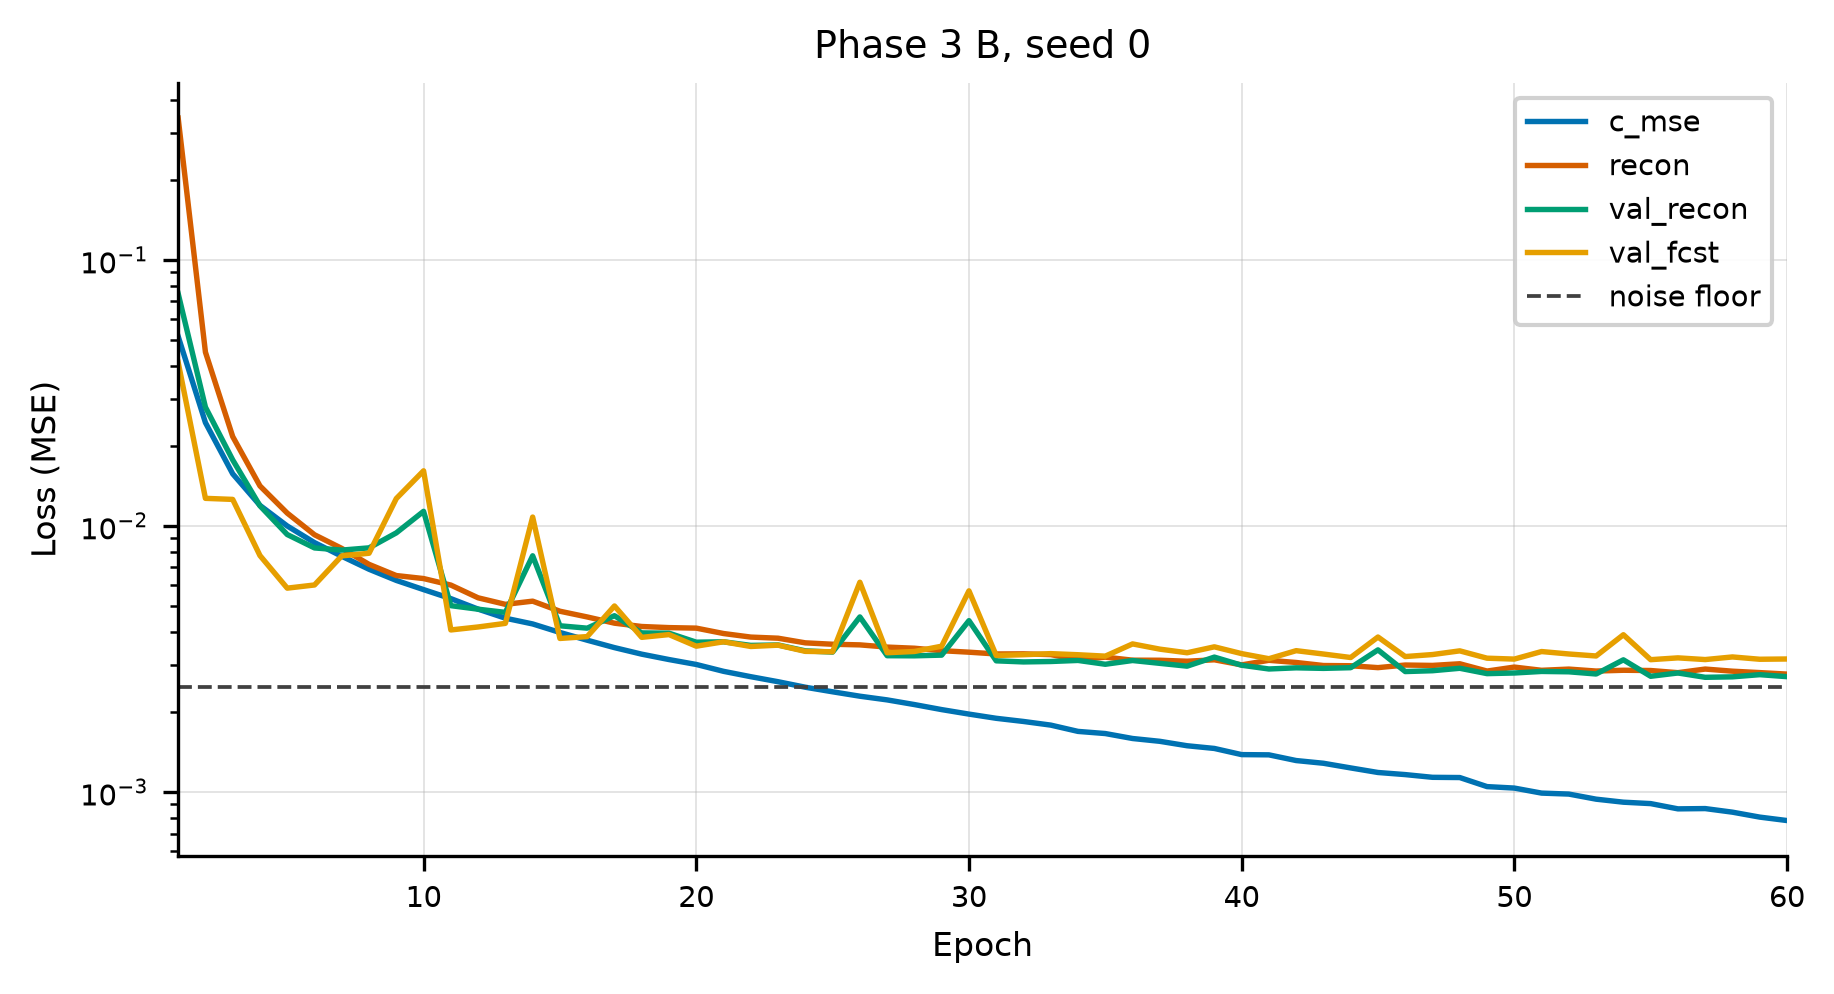

phase3 B seed 0 epoch 0060/60 | c_mse 7.830e-04 | recon 2.780e-03 | val_recon 2.719e-03 | val_fcst 3.168e-03
saved phase3B_seed0.pt


phase3 B seed 1:   0%|          | 0/60 [00:00<?, ?ep/s]

phase 3 B:   0%|          | 0/55 [00:00<?, ?it/s]

phase 3 B:   0%|          | 0/55 [00:00<?, ?it/s]

phase 3 B:   0%|          | 0/55 [00:00<?, ?it/s]

...

phase 3 B:   0%|          | 0/55 [00:00<?, ?it/s]

phase 3 B:   0%|          | 0/55 [00:00<?, ?it/s]

phase 3 B:   0%|          | 0/55 [00:00<?, ?it/s]

phase 3 B:   0%|          | 0/55 [00:00<?, ?it/s]

saved phase3B_seed2.pt
variant B done


In [10]:
@torch.no_grad()
def PrecomputePhase3(Model, Seq):
    """b_t and the C_t target. E, f and r are frozen, so both are constants."""
    Bn, T, n = Seq.shape
    h = Model.E(Seq.reshape(Bn * T, n))
    bT = Model.F(h).view(Bn, T, Model.k)
    CT = Model.R(h).view(Bn, T, Model.a, Model.b)
    return bT, CT


def MapC(Variant, Net, bseq, C0=None):
    if Variant == "A":
        Bn, T, k = bseq.shape
        Cs = Net(bseq.reshape(Bn * T, k)).view(Bn, T, A, B)
        return Cs, Cs[:, -1]
    return Net.ChainC(bseq, C0)


def Phase3Epoch(Variant, Net, Dec, Opt, bT, CT, X):
    """m and D only. Nothing upstream of m runs -- b and C are precomputed."""
    Perm = torch.randperm(bT.shape[0])
    Sums, Nb = [0.0, 0.0], 0
    Batches = tqdm(range(0, len(Perm), BATCH_P3), desc=f"phase 3 {Variant}", leave=False)
    for i in Batches:
        j = Perm[i:i + BATCH_P3]
        b, Ctgt, x = bT[j], CT[j], X[j]

        Chat, _ = MapC(Variant, Net, b)
        Bn, T = Chat.shape[:2]
        Xhat = Dec(Chat.reshape(Bn * T, A, B)).view(Bn, T, N)

        Lc, Lx = MseT(Chat, Ctgt), MseT(Xhat, x)
        Loss = Lc + Lx
        Opt.zero_grad(); Loss.backward(); Opt.step()
        Sums = [Sums[0] + Lc.item(), Sums[1] + Lx.item()]
        Nb += 1
        Batches.set_postfix(c=f"{Lc.item():.2e}", x=f"{Lx.item():.2e}")
    Nb = max(Nb, 1)
    return {"c_mse": Sums[0] / Nb, "recon": Sums[1] / Nb}


@torch.no_grad()
def ValPhase3(Model):
    Was = Model.training
    Model.eval()
    Out = {"val_recon": MseT(Model.Reconstruct(XValFull), XValFull).item(),
           "val_fcst": MseT(Model.Rollout(XValWarm, UNROLL), XValFut).item()}
    if Was:
        Model.train()
    return Out


def TrainPhase3(Variant, Seed, P2Model, Verbose=True):
    def Build():
        SeedAll(Seed + 1000)
        Base = P2Model
        if Variant == "A":
            return Base            # m carries over from phase 2 and is fine-tuned
        # B's map is a different shape and cannot inherit phase 2's static
        # weights, so it necessarily starts fresh -- see the asymmetry note.
        return DynamicMModel(Base, K, A, B).to(DEVICE)

    def Train(Model):
        Base = Model if Variant == "A" else Model.Base
        Target = Base.M if Variant == "A" else Model.MD
        if Verbose:
            AuditPhase(f"phase 3 {Variant}",
                       [("E", Base.E), ("r", Base.R), ("f", Base.F), ("g", Base.G),
                        ("m", Target), ("D", Base.D)],
                       Trainable=["m", "D"], Used=[])
            print("    (E, f, r run once in PrecomputePhase3; g never runs at all)")
        bT, CT = PrecomputePhase3(Base, XFull)
        Params = SetTrainable(Model, [Target, Base.D])
        Net = Target if Variant == "A" else Model
        Opt = torch.optim.Adam(Params, lr=LR)
        Hist = EpochTrain(
            lambda: Phase3Epoch(Variant, Net, Base.D, Opt, bT, CT, XFull),
            EvalFn=lambda: ValPhase3(Model),
            epochs=EPOCHS, marks=MARKS, name=f"phase3 {Variant} seed {Seed}",
            PlotFn=(lambda H: PlotLossCurves(
                {k: H[k] for k in ("c_mse", "recon", "val_recon", "val_fcst") if k in H},
                Floor=NOISE_FLOOR, Title=f"Phase 3 {Variant}, seed {Seed}")) if Verbose else None,
            plot_every=PLOT_EVERY, verbose=Verbose)
        del bT, CT
        return Hist

    return TrainOrLoad(CKPT_DIR / f"phase3{Variant}_seed{Seed}.pt", Build, Train, DEVICE)


VariantModels = {"A": [], "B": []}
VariantHists = {"A": [], "B": []}
for Variant in ("A", "B"):
    for Seed, P2 in zip(SEEDS, P2Models):
        # Each variant gets its own copy of phase 2: variant A replaces the
        # model's m in place and both variants fine-tune D, so sharing the
        # object would let A's phase 3 leak into B's starting point.
        _M, _H = TrainPhase3(Variant, Seed, copy.deepcopy(P2),
                             Verbose=(Seed == SEEDS[0]))
        VariantModels[Variant].append(_M); VariantHists[Variant].append(_H)
    print(f"variant {Variant} done")


## Results

The `Ours (two-stage)` row is the number from the main comparative study at the
same 60 epochs, 3 seeds and identical eval windows -- carried in as a constant
rather than retrained.


In [11]:
def Agg(Models, Label):
    Runs = [EvaluateModel(m, Warm, Fut, **EvalKw) for m in Models]
    Out = {"model": Label, "n_seeds": len(Runs)}
    for k in Runs[0]:
        if k == "curve":
            Out["curve"] = np.mean([r["curve"] for r in Runs], axis=0)
        elif isinstance(Runs[0][k], (int, float, bool)):
            V = [float(r[k]) for r in Runs]
            Out[k] = float(np.mean(V)); Out[k + "_std"] = float(np.std(V))
    return Out


Res = {"3-phase, static m (A)": Agg(VariantModels["A"], "3-phase, static m (A)"),
       "3-phase, dynamic m (B)": Agg(VariantModels["B"], "3-phase, dynamic m (B)")}

BASELINE_2PHASE = {"model": "Ours (two-stage, main nb)", "n_seeds": 3,
                   "recon_mse": 0.0038, "recon_nrmse": 0.0612, "vpt": 0.5738,
                   "vpt_std": 0.1225, "fcst_nrmse_full": 1.0951, "divergence": 0.0000}

Rows = [BASELINE_2PHASE] + list(Res.values())
Table = pd.DataFrame([{
    "model": r["model"],
    "seeds": r.get("n_seeds"),
    "recon MSE": r.get("recon_mse"),
    "x floor": (r.get("recon_mse") / NOISE_FLOOR) if r.get("recon_mse") else np.nan,
    "VPT (Lyap)": r.get("vpt"),
    "VPT std": r.get("vpt_std", 0.0),
    "NRMSE @ 5LT": r.get("fcst_nrmse_full"),
    "divergence": r.get("divergence"),
} for r in Rows]).round(4)
Table


,model,seeds,recon MSE,x floor,VPT (Lyap),VPT std,NRMSE @ 5LT,divergence
0,"Ours (two-stage, main nb)",3,0.0038,1.5248,0.5738,0.1225,1.0951,0.0
1,"3-phase, static m (A)",3,0.0025,1.0121,1.8029,0.0729,0.8216,0.0
2,"3-phase, dynamic m (B)",3,0.0029,1.1568,1.8029,0.0729,0.8187,0.0


In [12]:
# NB: do not bind these to A / B -- those are the bounded-latent dims.
ResA, ResB = Res["3-phase, static m (A)"], Res["3-phase, dynamic m (B)"]
Ref = BASELINE_2PHASE

print("axis            2-phase      3-phase A    3-phase B    winner")
print("-" * 68)
for Key, Label, Lower in [("recon_mse", "recon MSE", True),
                          ("vpt", "VPT", False),
                          ("fcst_nrmse_full", "NRMSE@5LT", True),
                          ("divergence", "divergence", True)]:
    v = [Ref[Key], ResA[Key], ResB[Key]]
    Best = int(np.argmin(v)) if Lower else int(np.argmax(v))
    Tie = " (tie)" if len(set(np.round(v, 6))) == 1 else ""
    print(f"{Label:15s} {v[0]:<12.4f} {v[1]:<12.4f} {v[2]:<12.4f} "
          f"{['2-phase', '3-phase A', '3-phase B'][Best]}{Tie}")

print("\nVPT spread across seeds (is any gap bigger than seed noise?):")
for L, R in [("2-phase", Ref), ("3-phase A", ResA), ("3-phase B", ResB)]:
    print(f"  {L:12s} VPT {R['vpt']:.4f} +/- {R.get('vpt_std', 0.0):.4f}")


axis            2-phase      3-phase A    3-phase B    winner
--------------------------------------------------------------------
recon MSE       0.0038       0.0025       0.0029       3-phase A
VPT             0.5738       1.8029       1.8029       3-phase A
NRMSE@5LT       1.0951       0.8216       0.8187       3-phase B
divergence      0.0000       0.0000       0.0000       2-phase (tie)

VPT spread across seeds (is any gap bigger than seed noise?):
  2-phase      VPT 0.5738 +/- 0.1225
  3-phase A    VPT 1.8029 +/- 0.0729
  3-phase B    VPT 1.8029 +/- 0.0729


In [13]:
# Boundedness must survive both maps -- it is the property the whole argument
# rests on. Variant B advances C recursively for 5,500 steps, so if the
# logit-space residual leaks at all, this is where it shows.
print(f"C outside [0,1] over {CLIMATE} steps x {WarmC.shape[0]} rollouts:")
with torch.no_grad():
    _, _, CsA = VariantModels["A"][0].RolloutLatents(WarmC, CLIMATE)
    CsB = VariantModels["B"][0].RolloutC(WarmC, CLIMATE)
for Label, Cs in [("static m (A) ", CsA), ("dynamic m (B)", CsB)]:
    Np = Cs.cpu().numpy()
    print(f"  {Label}: {BoundViolation(Np):.6f}   saturated {Saturation(Np):.4f}   "
          f"min {Np.min():.4f} max {Np.max():.4f}")


C outside [0,1] over 5500 steps x 32 rollouts:
  static m (A) : 0.000000   saturated 0.0839   min 0.0000 max 1.0000
  dynamic m (B): 0.000000   saturated 0.2607   min 0.0000 max 1.0000


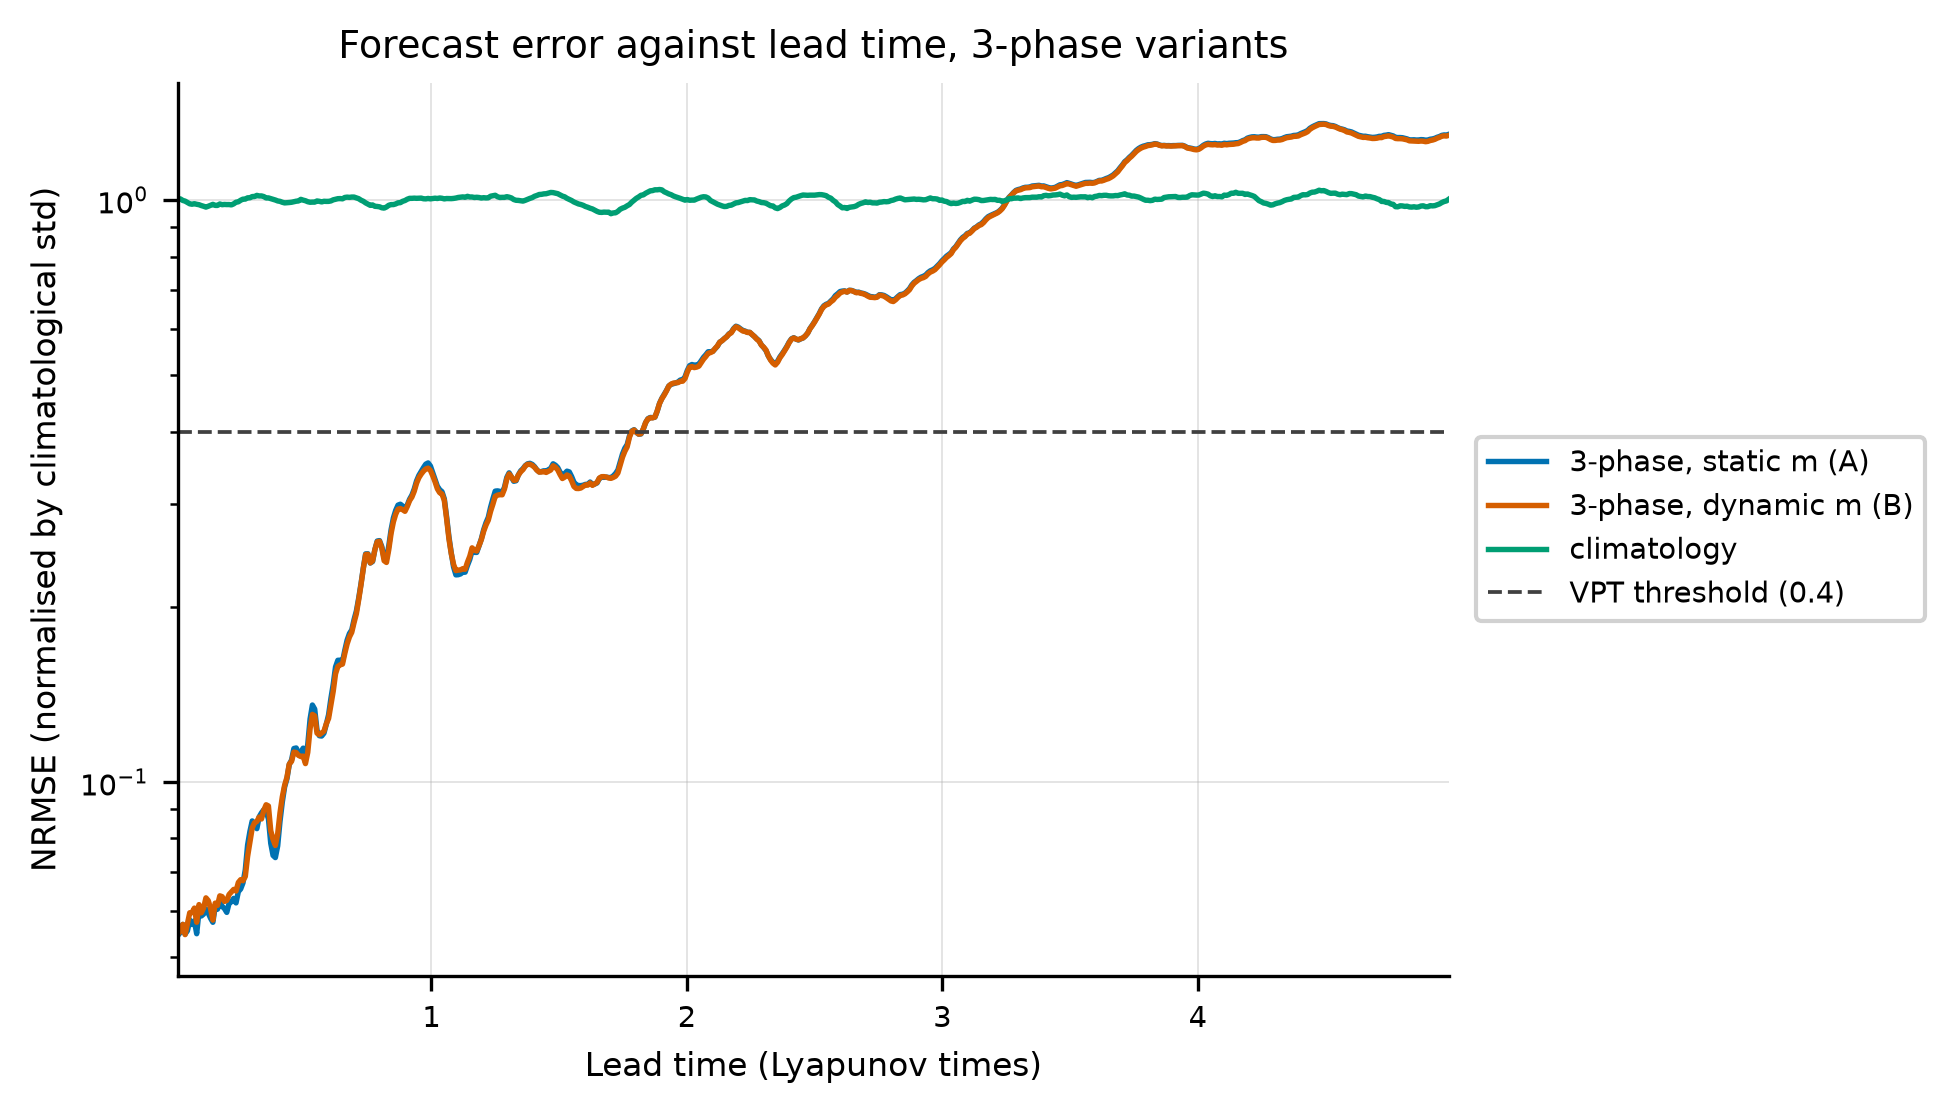

In [14]:
Curves = {"3-phase, static m (A)": Res["3-phase, static m (A)"]["curve"],
          "3-phase, dynamic m (B)": Res["3-phase, dynamic m (B)"]["curve"],
          "climatology": ForecastMetrics(
              FutNp, MeanRollout(WarmNp, HORIZON, train.mean(0)),
              DT, THRESHOLD, SCALE, BOUNDS)["curve"]}

Fig, Ax = PlotHorizonCurves(Curves, Dt=DT, Lam=LAMBDA_MAX, Threshold=THRESHOLD,
                            Title="Forecast error against lead time, 3-phase variants")
Ax.set_yscale("log")
plt.show()
